In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

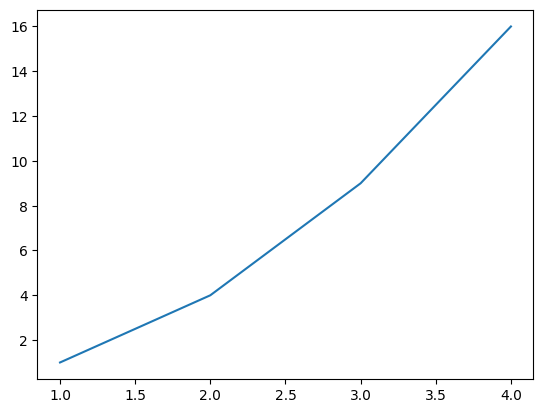

In [ ]:
# prosty wykres z list

plt.plot([1,2,3,4],[1,4,9,16])
plt.show()


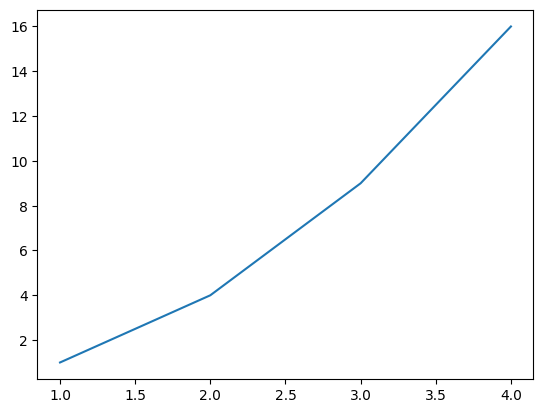

In [ ]:
#aby zachowac rezuzywalnosc wykresu, moc go zachowac itp.

fig, ax= plt.subplots()
ax.plot([1,2,3,4],[1,4,9,16])
plt.show()

In [ ]:
pogoda = pd.read_csv('/content/sample_data/Weather_Data.csv')
pogoda.head(10)

,Day,Temperature,Humidity,Wind_Speed
0,2023-01-01,28.8,55.4,8.7
1,2023-01-02,22.0,66.4,24.1
2,2023-01-03,24.9,31.2,18.7
3,2023-01-04,31.2,48.1,9.3
4,2023-01-05,29.3,69.6,23.9
5,2023-01-06,15.1,47.4,19.6
6,2023-01-07,24.8,67.1,10.1
7,2023-01-08,19.2,55.7,9.3
8,2023-01-09,19.5,38.1,15.4
9,2023-01-10,22.1,47.9,5.5


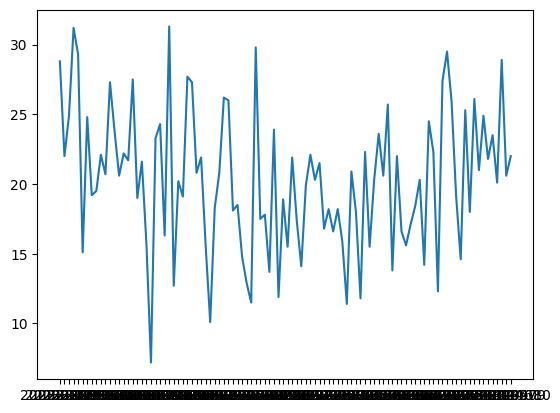

In [ ]:
#wykres na podstawie df

plt.plot(pogoda['Day'], pogoda['Temperature'])
plt.show()

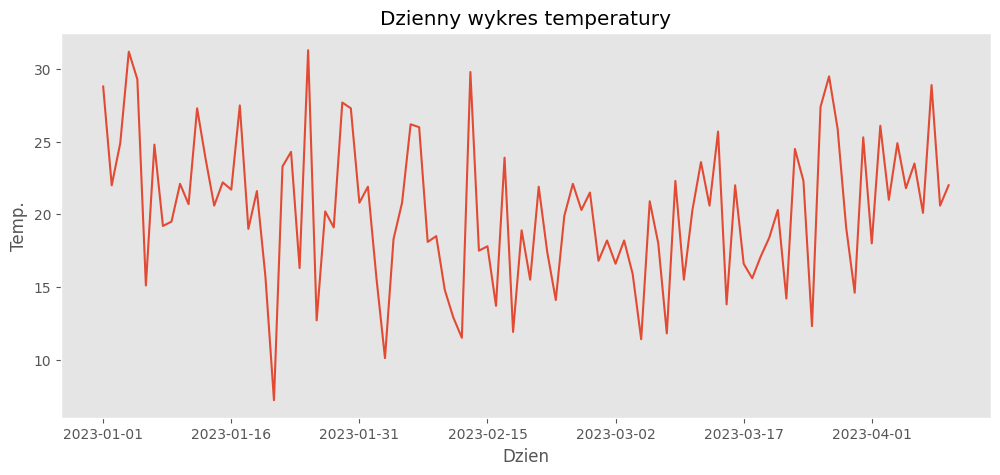

In [ ]:
plt.style.use('ggplot')
plt.figure(figsize=(12,5))
plt.plot(pogoda['Day'], pogoda['Temperature'])
plt.title("Dzienny wykres temperatury")
plt.xlabel("Dzien")
plt.ylabel("Temp.")
plt.grid(False)
plt.xticks(np.arange(0,100,15)) #start, stop, step
plt.show()

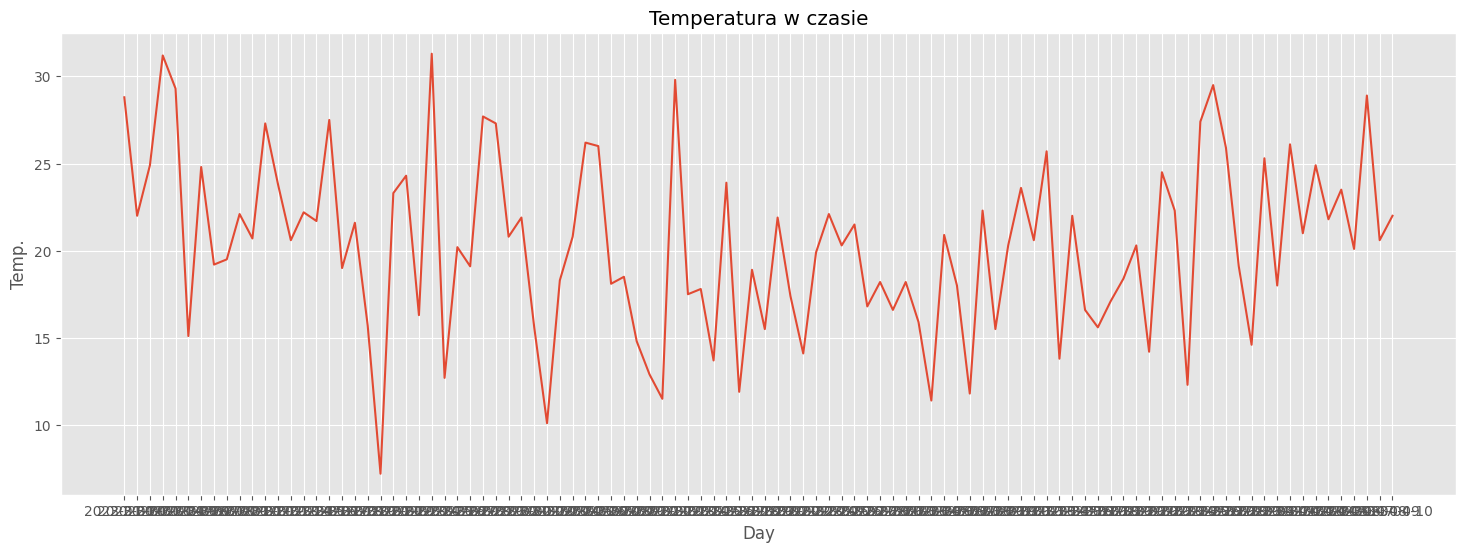

In [ ]:
fig_temp, ax_temp = plt.subplots(figsize=(18,6))
ax_temp.plot(pogoda['Day'], pogoda ['Temperature'])
ax_temp.set_title("Temperatura w czasie")
ax_temp.set_xlabel("Day")
ax_temp.set_ylabel("Temp.")
plt.show()

In [ ]:
pogoda.head()

,Day,Temperature,Humidity,Wind_Speed
0,2023-01-01,28.8,55.4,8.7
1,2023-01-02,22.0,66.4,24.1
2,2023-01-03,24.9,31.2,18.7
3,2023-01-04,31.2,48.1,9.3
4,2023-01-05,29.3,69.6,23.9


In [ ]:
#wykres na podstawie grupowanych danych - krok 1

pogoda['Month']= pd.to_datetime(pogoda['Day']).dt.month
pogoda.head(10)

monthly_temp= pogoda.groupby('Month')['Temperature'].mean().reset_index()
monthly_temp


,Month,Temperature
0,1,22.167742
1,2,18.489286
2,3,19.287097
3,4,22.690000


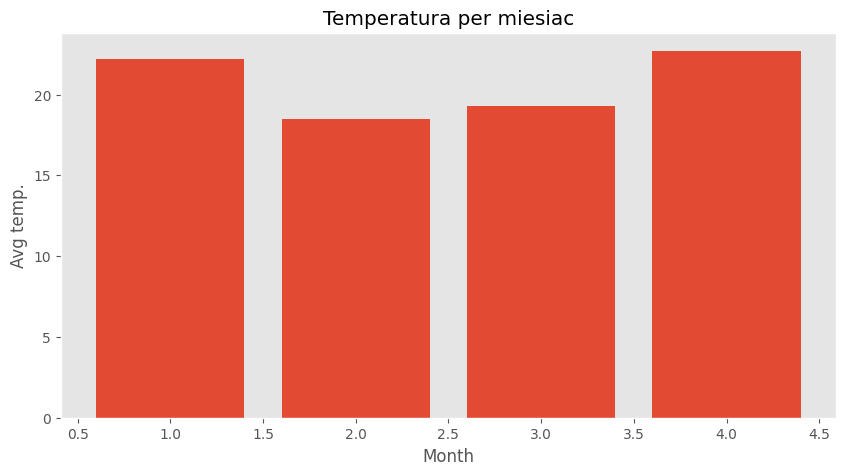

In [ ]:
#wykres na podstawie grupowanych danych - krok 2

fig_bar, ax_bar = plt.subplots(figsize=(10,5))

#plt.figure(figsize=(10,50))
ax_bar.bar(monthly_temp['Month'], monthly_temp['Temperature'])
ax_bar.set_title("Temperatura per miesiac")
ax_bar.grid(False)
ax_bar.set_xlabel("Month")
ax_bar.set_ylabel("Avg temp.")
plt.show()

In [ ]:
# wykres kolowy - przygotowanie danych

pogoda['Humidity Category']= pd.cut(pogoda['Humidity'], bins=[30,50,70,90], labels=['Low','Medium','High'])
pogoda


,Day,Temperature,Humidity,Wind_Speed,Month,Humidity Category
0,2023-01-01,28.8,55.4,8.7,1,Medium
1,2023-01-02,22.0,66.4,24.1,1,Medium
2,2023-01-03,24.9,31.2,18.7,1,Low
3,2023-01-04,31.2,48.1,9.3,1,Low
4,2023-01-05,29.3,69.6,23.9,1,Medium
...,...,...,...,...,...,...
95,2023-04-06,23.5,79.9,19.5,4,High
96,2023-04-07,20.1,67.7,10.4,4,Medium
97,2023-04-08,28.9,82.4,7.6,4,High
98,2023-04-09,20.6,46.4,6.1,4,Low


In [ ]:
humidity_counts = pogoda['Humidity Category'].value_counts()
humidity_counts

,count
Humidity Category,
Medium,35
Low,34
High,31


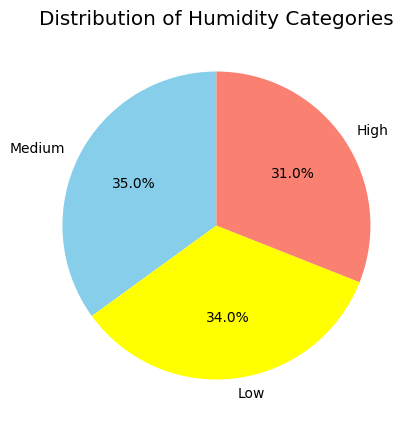

In [ ]:
#tworzenie wykresu kolowego

fig_pie, ax_pie = plt.subplots(figsize = (5,5))

ax_pie.pie(
    humidity_counts,
    labels=humidity_counts.index,
    colors=['skyblue','yellow','salmon'],
    autopct='%1.1f%%',
    startangle=90
)
ax_pie.set_title('Distribution of Humidity Categories')
plt.show()

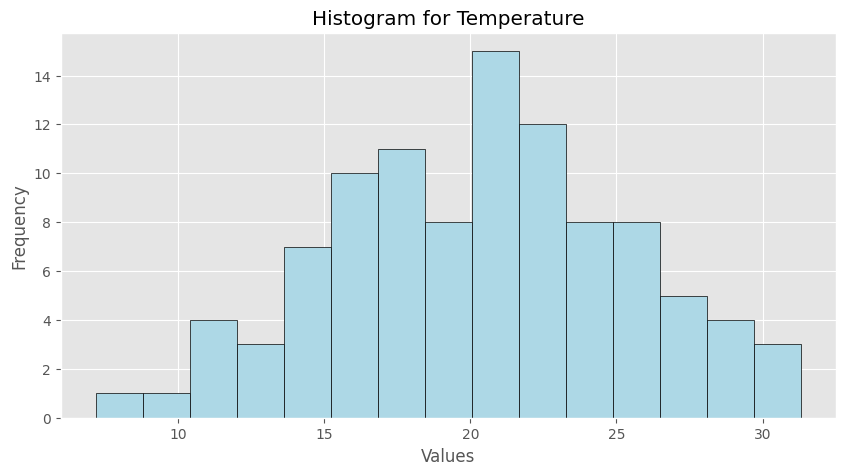

In [ ]:
#histogram

fix_hist, ax_hist = plt.subplots(figsize = (10,5))

ax_hist.hist(
    pogoda['Temperature'],
    bins=15,
    color='lightblue',
    edgecolor= 'black'
)

ax_hist.set_xlabel('Values')
ax_hist.set_ylabel('Frequency')
ax_hist.set_title('Histogram for Temperature')

plt.show()


fix_hist.savefig("histogram.png", format='png')

In [ ]:
import matplotlib.dates as mdates

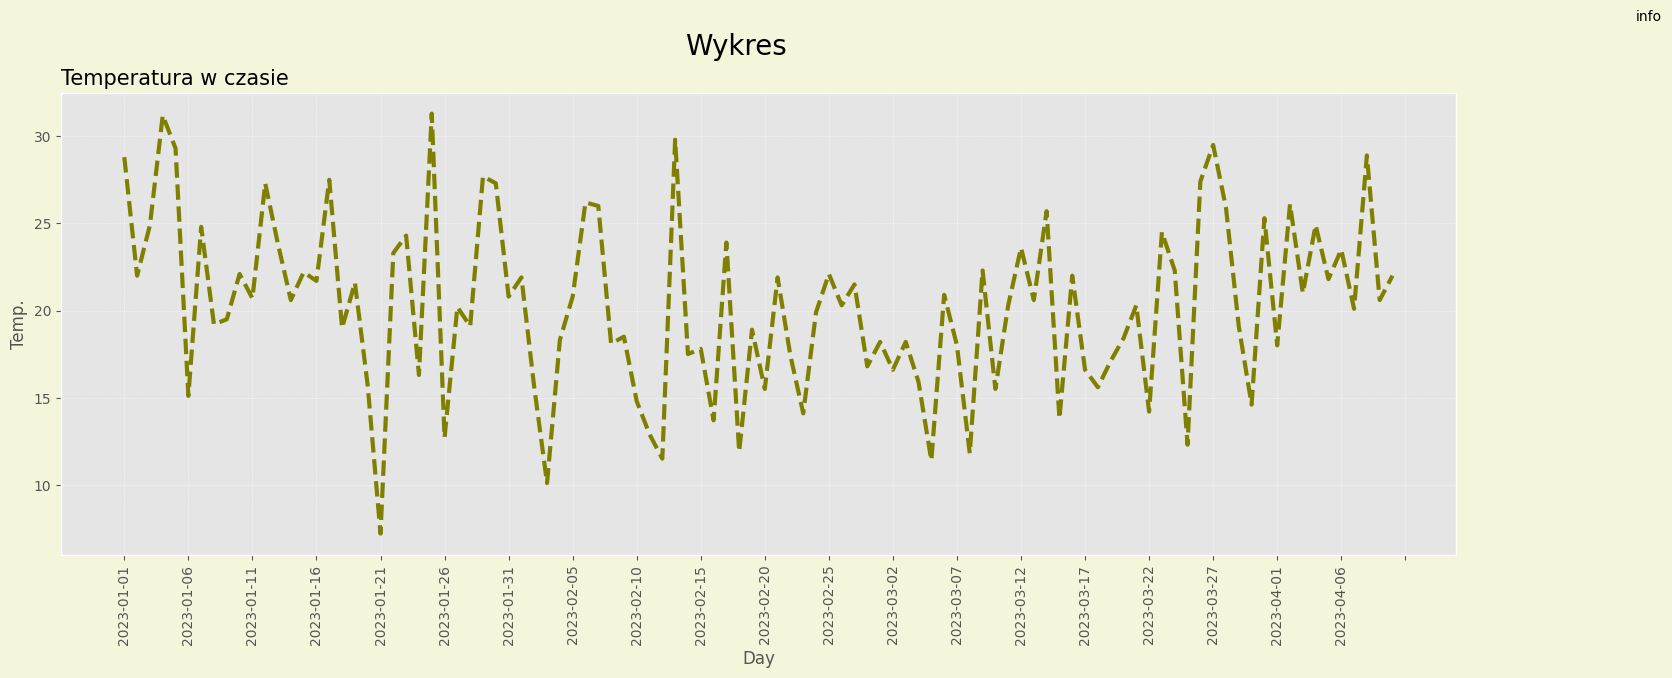

In [ ]:
#formatowanie i edycja wizualna wykresu

fig_temp, ax_temp = plt.subplots(figsize=(18,6))
ax_temp.plot(pogoda['Day'],
             pogoda ['Temperature'],
             color='olive',
             linestyle= 'dashed',
             linewidth=3
             )

ax_temp.set_title("Temperatura w czasie",
                  fontsize=15,
                  loc='left'
                  )

ax_temp.set_xlabel("Day")
ax_temp.set_ylabel("Temp.")
ax_temp.grid(True,
             linestyle=':',
             linewidth=0.5
)

ax_temp.tick_params(axis='x', rotation=90)
ax_temp.xaxis.set_major_locator(mdates.DayLocator(interval=5))

fig_temp.patch.set_facecolor('beige')
fig_temp.text(1,1,"info")
fig_temp.suptitle("Wykres",fontsize=20)



plt.show()

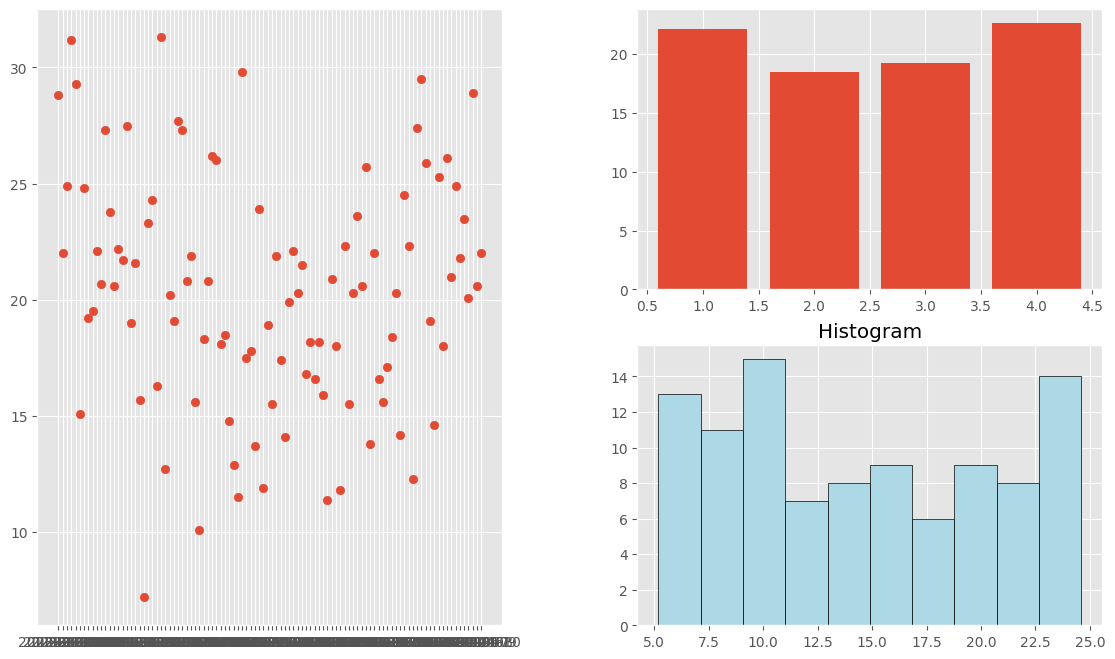

In [ ]:
#kilka wykresow na jednym figure

fig = plt.figure (figsize=(12,8))

subfig_left, subfig_right = fig.subfigures (1,2)

ax_left = subfig_left.subplots()
ax_left.scatter(pogoda['Day'], pogoda['Temperature'])


ax_right= subfig_right.subplots(2,1)

ax_right[0].bar(monthly_temp['Month'],monthly_temp['Temperature'])

ax_right[1].hist(pogoda['Wind_Speed'], bins = 10, color='lightblue', edgecolor='black')
ax_right[1].set_title("Histogram")

plt.show()